Kaiming Uniform initialization, SGD with learning rate = 0.001, momentum=0.9

Identity + Flipped (111)

In [1]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *

In [2]:
center_list = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [1,1,1]]
var_list = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*5
test_centers = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
test_vars = [ [[0.001, 0, 0], [0, 0.001, 0], [0, 0, 0.001] ]]*8
# hidd_list = [128, 256, 512, 1024, 2048]
hidd_list = [128, 2048]
n_hiddDim = len(hidd_list)
# defaults
n_test = 20
k, lo, hi, step = 10, 100, 110, 10
loss_n = range(lo, hi, step)

In [3]:
eval_list = [[] for _ in range(n_hiddDim)]  # list of test evaluations
losses_list = [[] for _ in range(n_hiddDim)]    # list of training loss histories
test_points_list = [[] for _ in range(n_hiddDim)]    # list of test points
weights_list = [[] for _ in range(n_hiddDim)]   # list of learned model weights
norms_list = [[] for _ in range(n_hiddDim)]     # list of norms of learned model weights

In [5]:
hidden_dim = [hidd_list[0]]
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.001, use_init="he")
eval_list[0] = evals
losses_list[0] = losses
test_points_list[0] = test_points
weights_list[0] = weights
norms_list[0] = norms

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


In [6]:
hidden_dim = [hidd_list[1]]
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.001, use_init="he")
eval_list[1] = evals
losses_list[1] = losses
test_points_list[1] = test_points
weights_list[1] = weights
norms_list[1] = norms

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


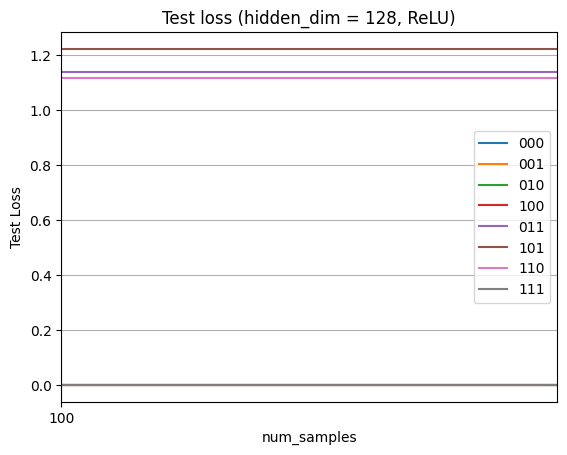

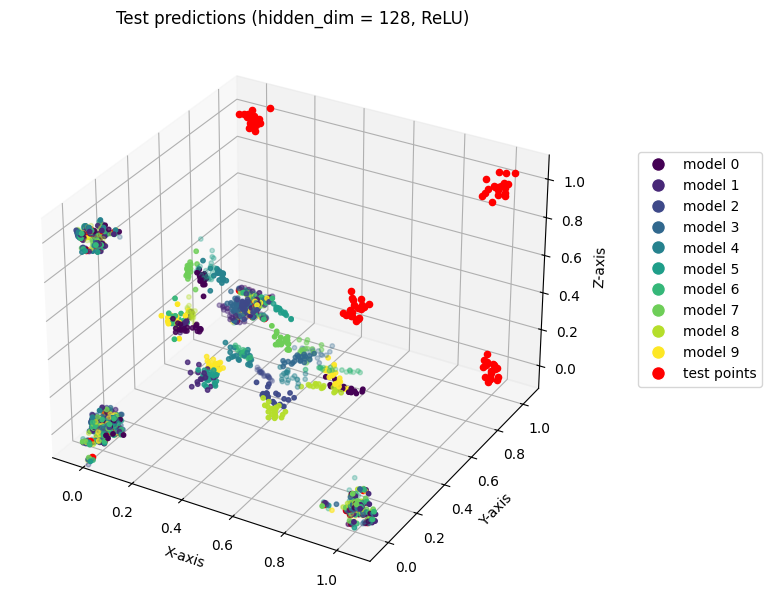

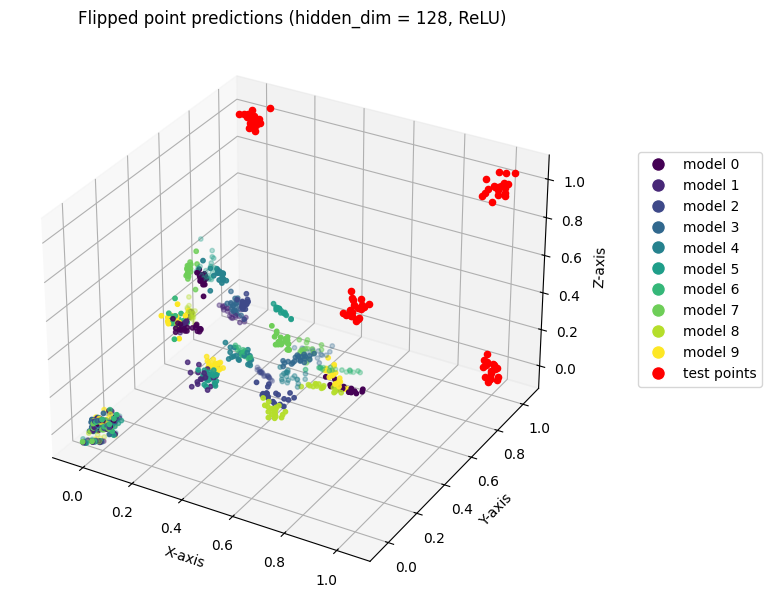

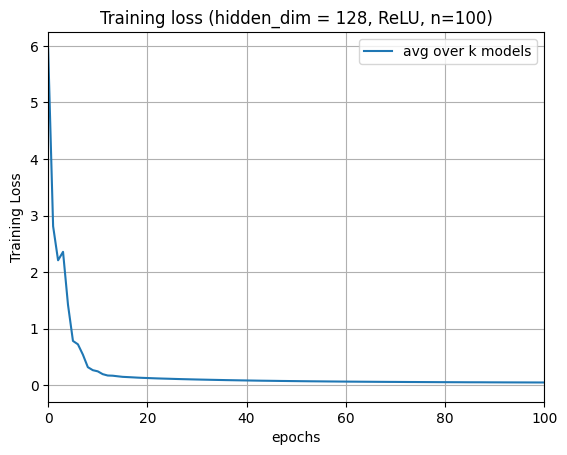

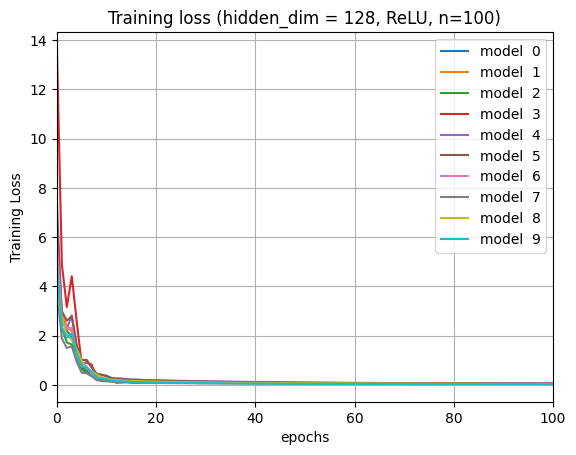

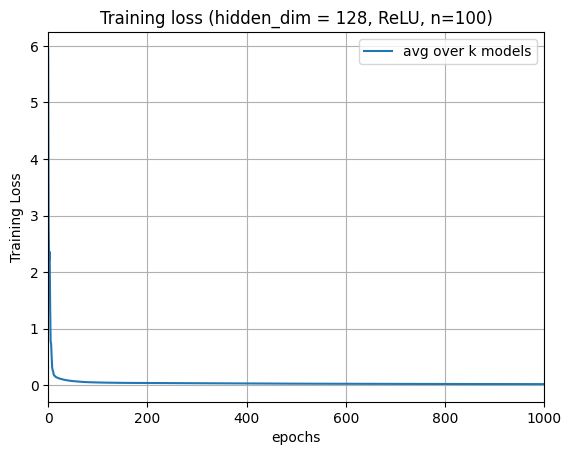

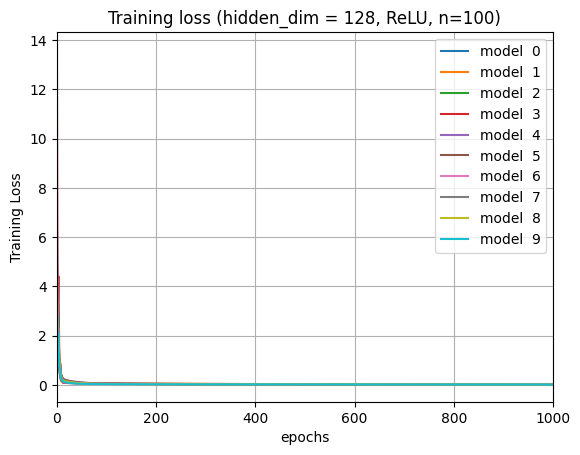

Final training loss for trial 0: 0.004581468994729221
Final training loss for trial 1: 0.0013584368862211704
Final training loss for trial 2: 0.006208931328728795
Final training loss for trial 3: 0.006741339049767703
Final training loss for trial 4: 0.0011445252894191071
Final training loss for trial 5: 0.00687400926835835
Final training loss for trial 6: 0.008842744340654463
Final training loss for trial 7: 0.0015871440700720996
Final training loss for trial 8: 0.005881441873498261
Final training loss for trial 9: 0.005448303127195686


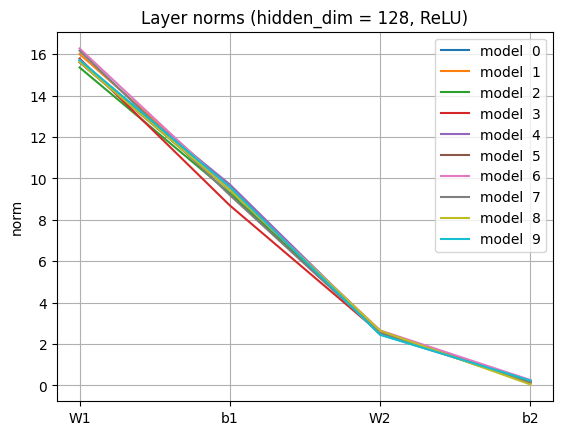

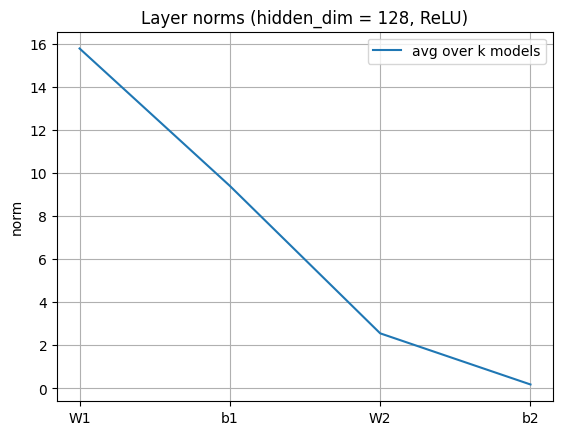

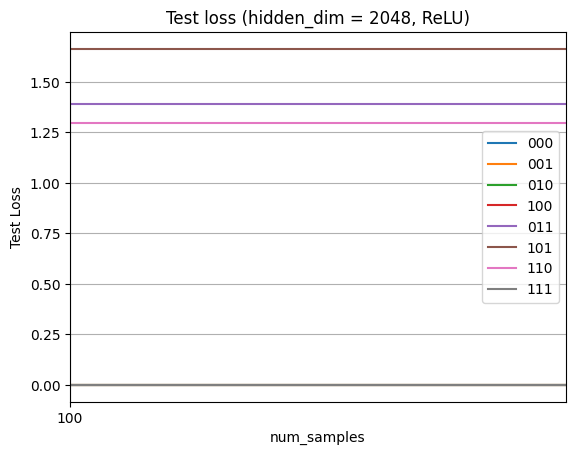

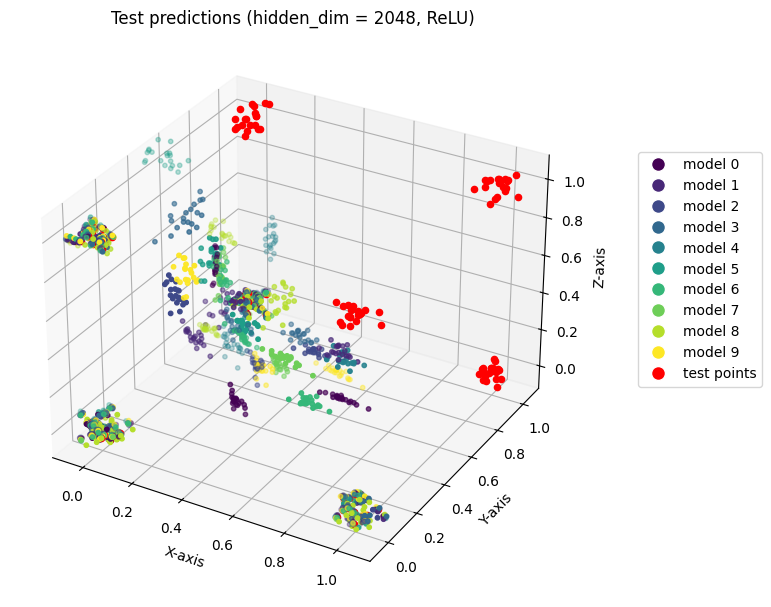

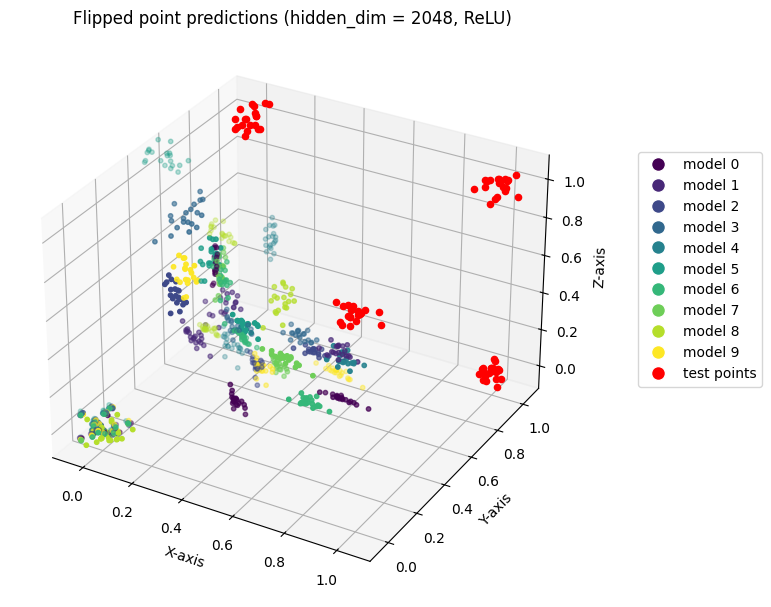

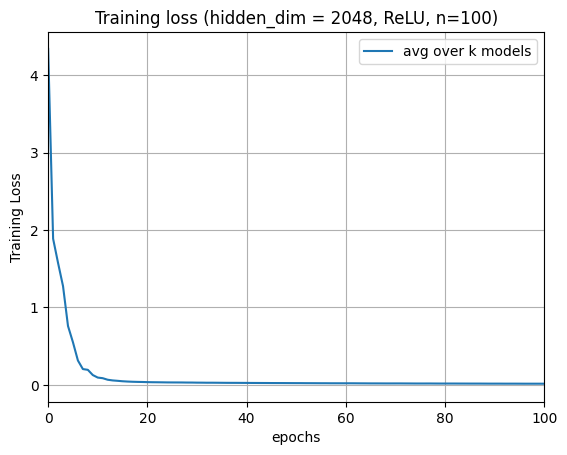

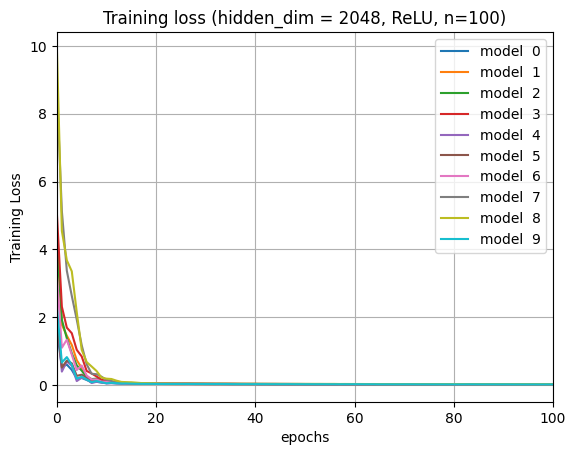

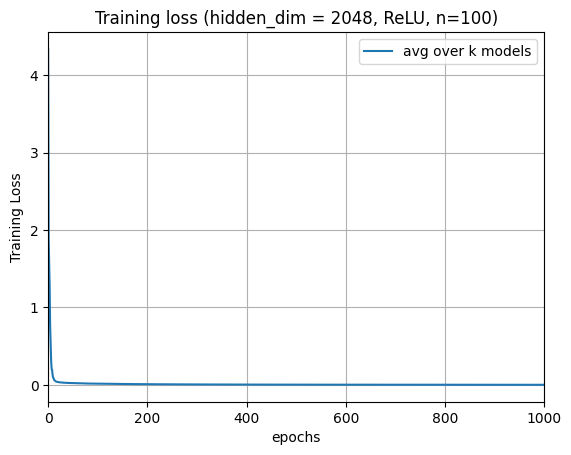

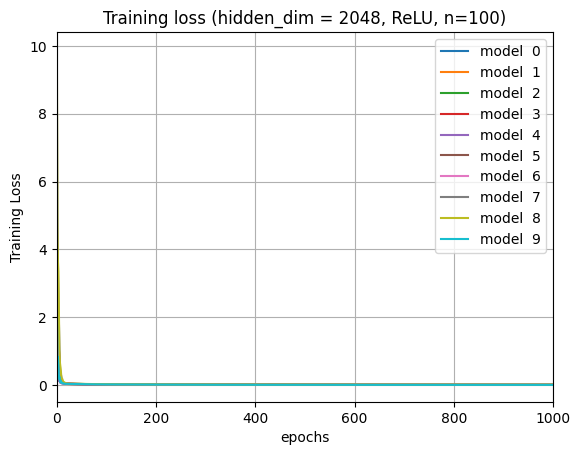

Final training loss for trial 0: 0.00022388261641026475
Final training loss for trial 1: 0.00023838638298911974
Final training loss for trial 2: 0.0002783452182484325
Final training loss for trial 3: 0.000269879586994648
Final training loss for trial 4: 0.00025510561681585386
Final training loss for trial 5: 0.0018227446707896888
Final training loss for trial 6: 0.00025637022918090224
Final training loss for trial 7: 0.00023751112894387916
Final training loss for trial 8: 0.0027466050451039337
Final training loss for trial 9: 0.0002623379841679707


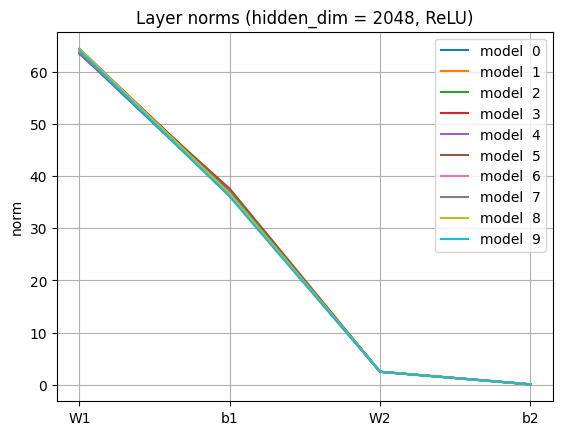

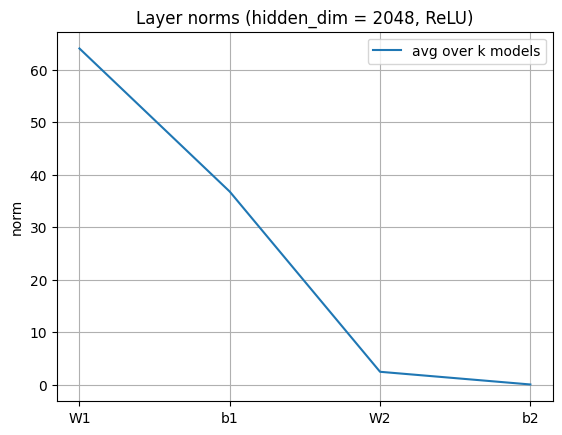

In [7]:
testLoss_list = [[] for _ in range(n_hiddDim)]

for i in range(n_hiddDim):
    hidden_dim = hidd_list[i]
    testLoss = compute_clusterLoss(eval_list[i], flippedIdentity(test_points_list[i]), test_centers)
    plot_clusterTestLoss(np.hstack((testLoss, testLoss)), test_centers, hidden_dim)
    testLoss_list[i] = np.reshape(testLoss, (8))
    
    scatter_testPredictions(eval_list[i], test_points_list[i], hidden_dim, test_ids=range(8))
    scatter_testPredictions(eval_list[i], test_points_list[i], hidden_dim, test_ids=range(4,8), title='Flipped point predictions (hidden_dim = %s, ' % hidden_dim + 'ReLU)')
    
    plot_list = range(len(loss_n))
    plot_trainingLoss(np.mean(losses_list[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=100)
    plot_trainingLoss(losses_list[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=100)
    plot_trainingLoss(np.mean(losses_list[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=1000)
    plot_trainingLoss(losses_list[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=1000)
    for j in range(k):
        print("Final training loss for trial " + str(j) + ": " + str(losses_list[i][0][j][-1]))

    plot_norms(norms_list[i], hidden_dim)
    plot_norms(np.mean(norms_list[i], axis=1, keepdims=True), hidden_dim)

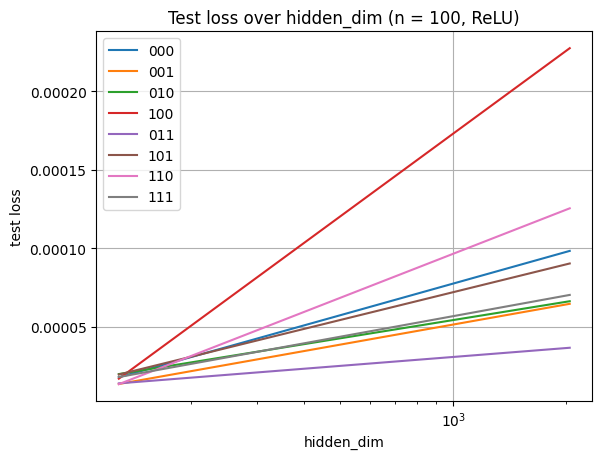

In [ ]:
plot_hiddDim(np.array(testLoss_list), test_centers, hidd_list, lo=100)

---
Identity + Flipped (110)

In [ ]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *

In [8]:
center_list = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [1,1,0]]
var_list = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*5
test_centers = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
test_vars = [ [[0.001, 0, 0], [0, 0.001, 0], [0, 0, 0.001] ]]*8
# hidd_list = [128, 256, 512, 1024, 2048]
hidd_list = [128, 2048]
n_hiddDim = len(hidd_list)
# defaults
n_test = 20
k, lo, hi, step = 10, 100, 110, 10
loss_n = range(lo, hi, step)

In [9]:
eval_list_110 = [[] for _ in range(n_hiddDim)]  # list of test evaluations
losses_list_110 = [[] for _ in range(n_hiddDim)]    # list of training loss histories
test_points_list_110 = [[] for _ in range(n_hiddDim)]    # list of test points
weights_list_110 = [[] for _ in range(n_hiddDim)]   # list of learned model weights
norms_list_110 = [[] for _ in range(n_hiddDim)]     # list of norms of learned model weights

In [10]:
hidden_dim = [hidd_list[0]]
evals_110, test_points_110, losses_110, weights_110, norms_110 = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.001, use_init="he")
eval_list_110[0] = evals_110
losses_list_110[0] = losses_110
test_points_list_110[0] = test_points_110
weights_list_110[0] = weights_110
norms_list_110[0] = norms_110

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


In [11]:
hidden_dim = [hidd_list[1]]
evals_110, test_points_110, losses_110, weights_110, norms_110 = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.001, use_init="he")
eval_list_110[1] = evals_110
losses_list_110[1] = losses_110
test_points_list_110[1] = test_points_110
weights_list_110[1] = weights_110
norms_list_110[1] = norms_110

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


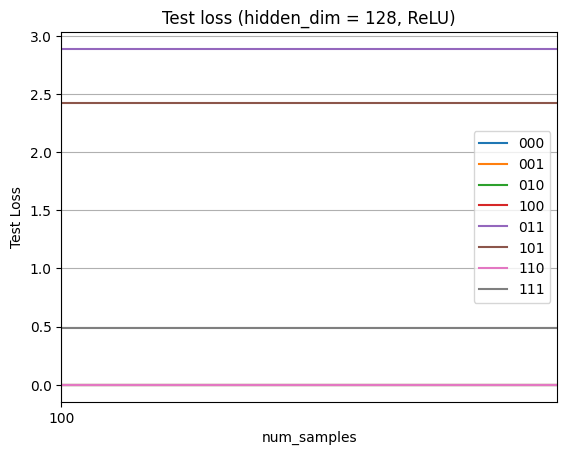

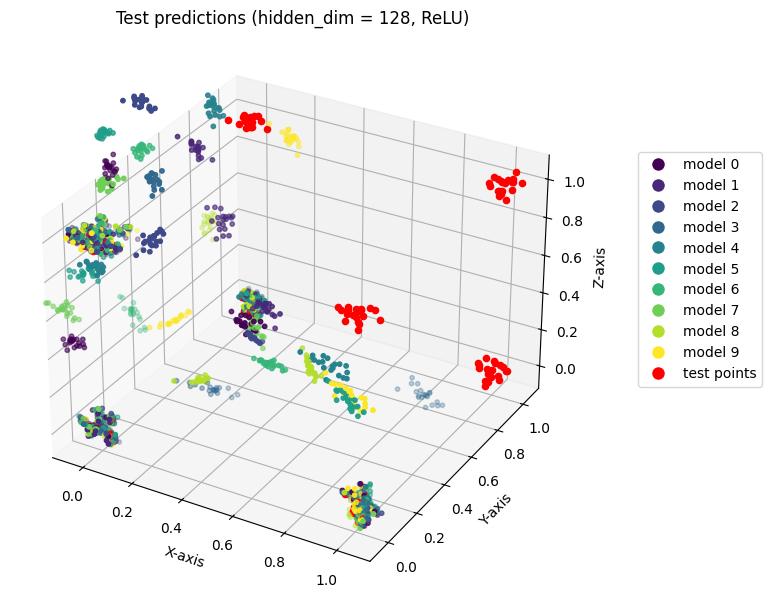

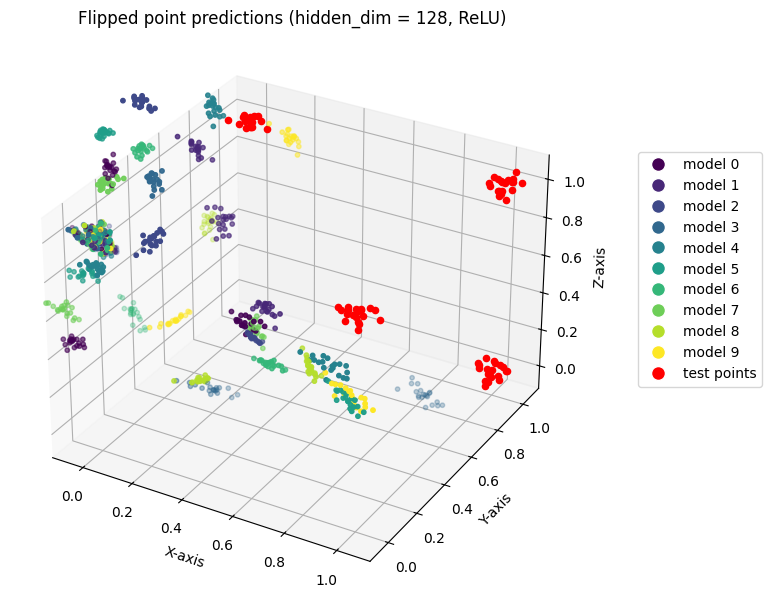

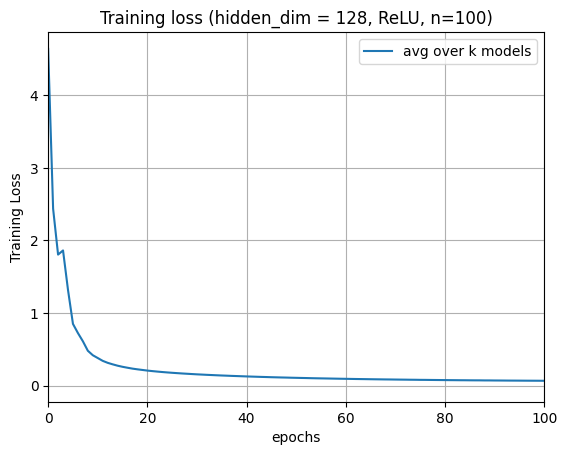

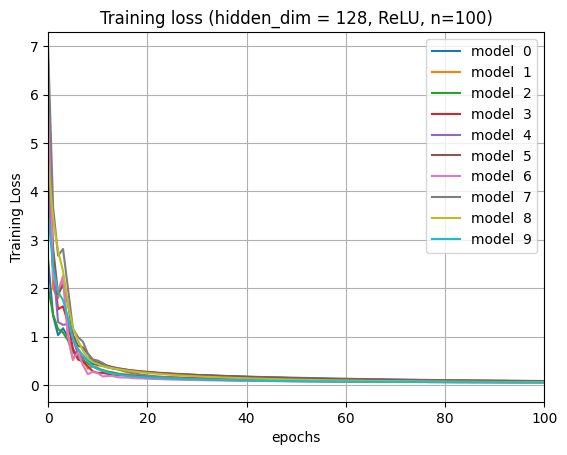

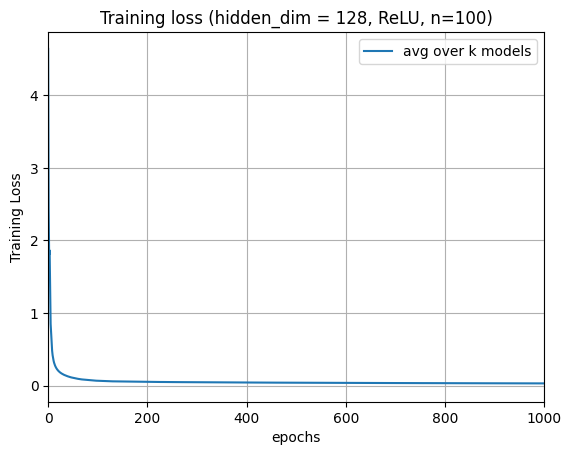

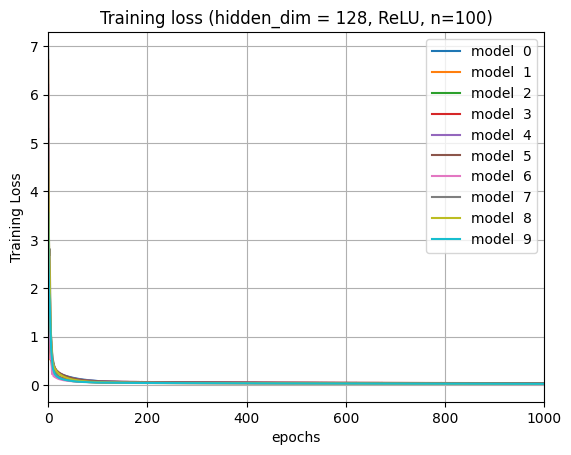

Final training loss for trial 0: 0.009614680253434926
Final training loss for trial 1: 0.007892665278632194
Final training loss for trial 2: 0.010264876473229378
Final training loss for trial 3: 0.017643831088207662
Final training loss for trial 4: 0.006062152562662959
Final training loss for trial 5: 0.013162466697394848
Final training loss for trial 6: 0.002181604679208249
Final training loss for trial 7: 0.007287614978849888
Final training loss for trial 8: 0.0036742486408911645
Final training loss for trial 9: 0.008465067425277084


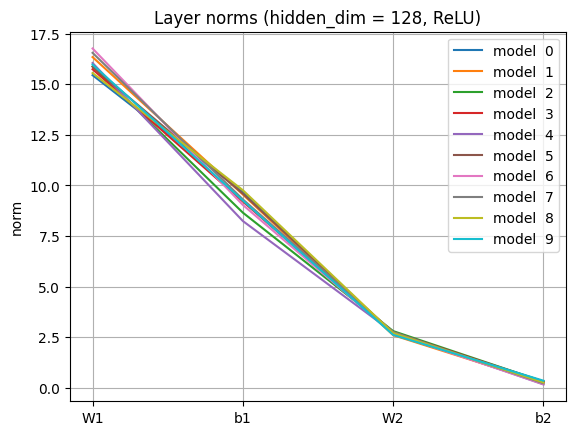

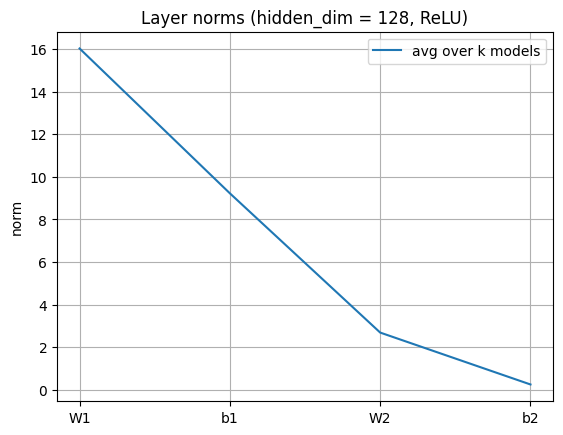

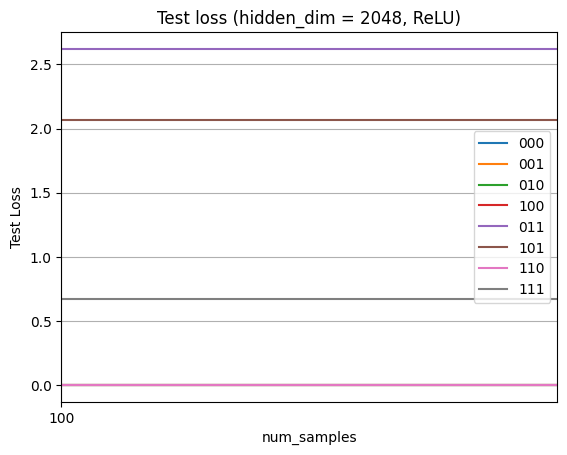

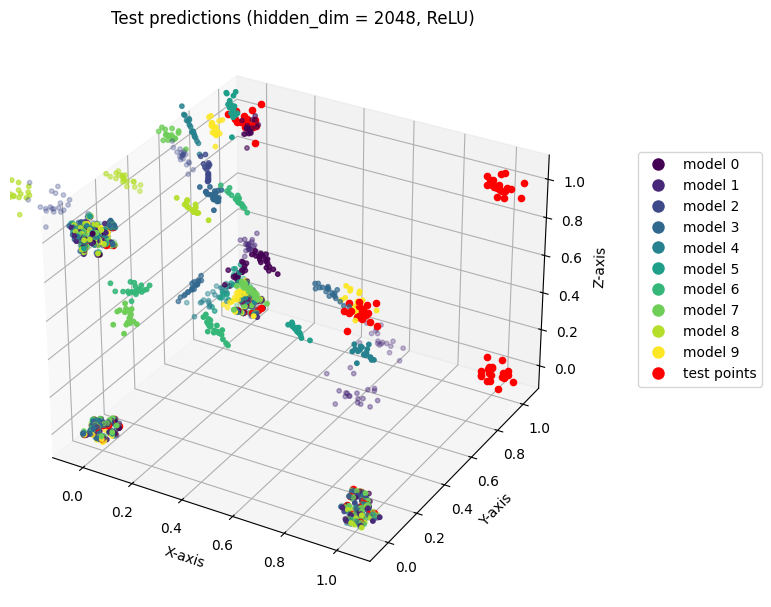

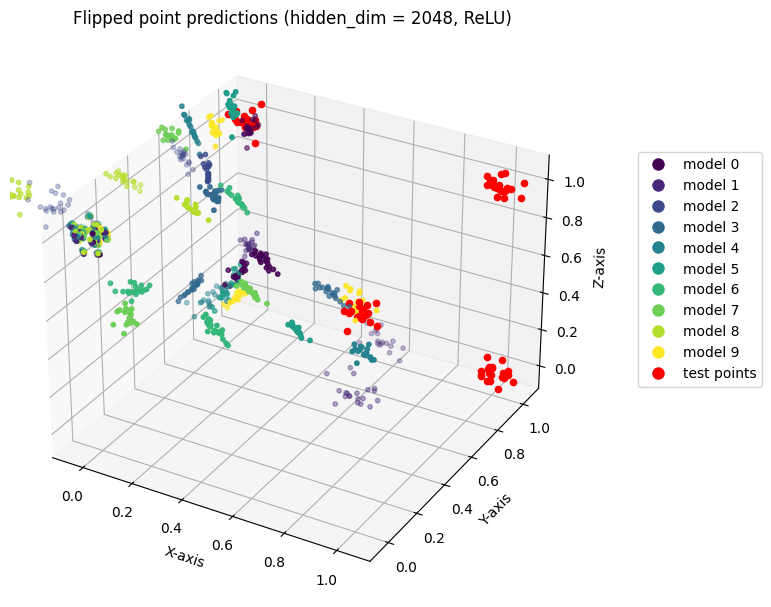

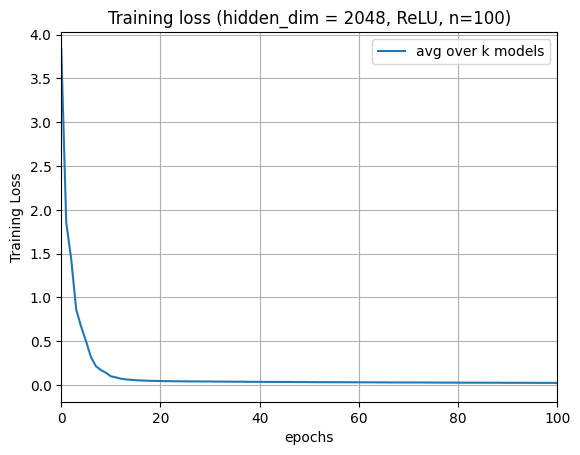

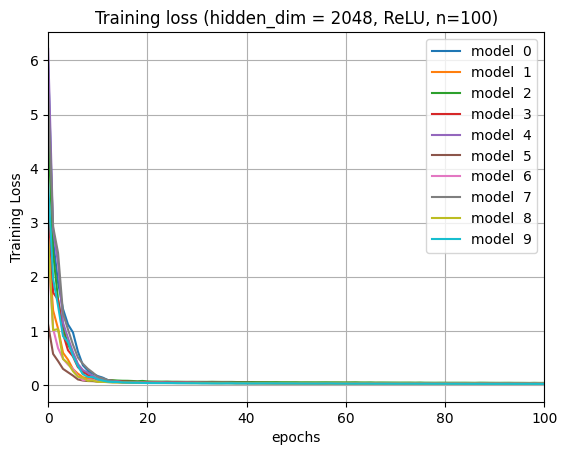

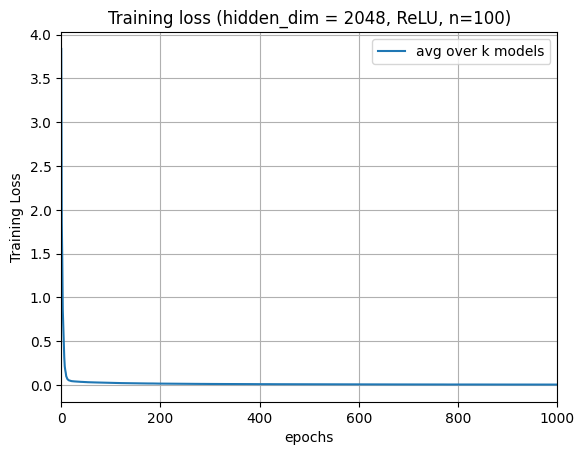

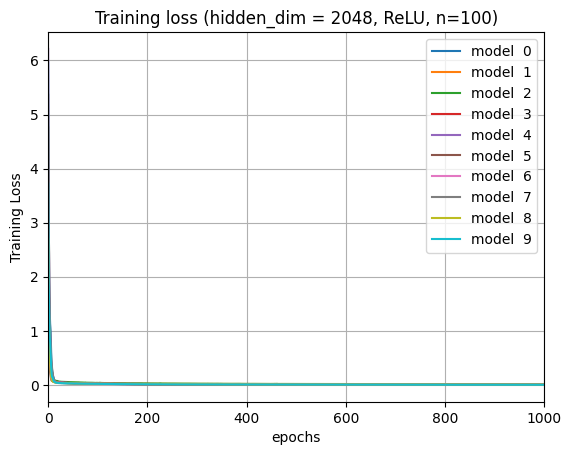

Final training loss for trial 0: 0.0005459430612972938
Final training loss for trial 1: 0.005697934713680297
Final training loss for trial 2: 0.004770959552843124
Final training loss for trial 3: 0.0005352361768018454
Final training loss for trial 4: 0.0005523341606021859
Final training loss for trial 5: 0.0004853886639466509
Final training loss for trial 6: 0.003153342957375571
Final training loss for trial 7: 0.0006544349234900437
Final training loss for trial 8: 0.0020678183500422165
Final training loss for trial 9: 0.0006276407075347379


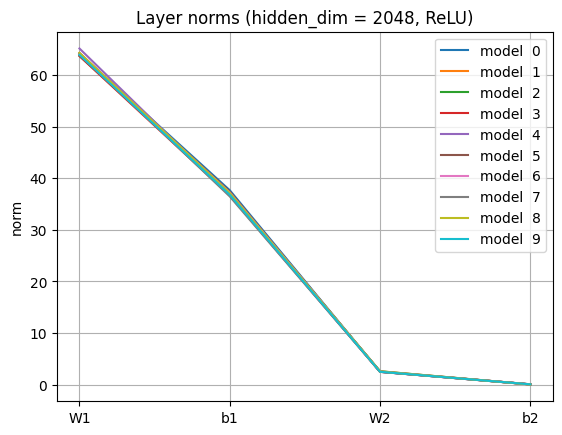

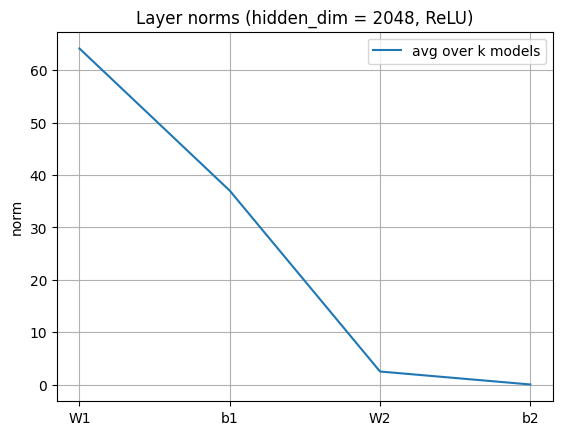

In [12]:
testLoss_list_110 = [[] for _ in range(n_hiddDim)]

for i in range(n_hiddDim):
    hidden_dim = hidd_list[i]
    testLoss_110 = compute_clusterLoss(eval_list_110[i], flippedIdentity(test_points_list_110[i]), test_centers)
    plot_clusterTestLoss(np.hstack((testLoss_110, testLoss_110)), test_centers, hidden_dim)
    testLoss_list_110[i] = np.reshape(testLoss_110, (8))
    
    scatter_testPredictions(eval_list_110[i], test_points_list_110[i], hidden_dim, test_ids=range(8))
    scatter_testPredictions(eval_list_110[i], test_points_list_110[i], hidden_dim, test_ids=range(4,8), title='Flipped point predictions (hidden_dim = %s, ' % hidden_dim + 'ReLU)')
    
    plot_list = range(len(loss_n))
    plot_trainingLoss(np.mean(losses_list_110[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=100)
    plot_trainingLoss(losses_list_110[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=100)
    plot_trainingLoss(np.mean(losses_list_110[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=1000)
    plot_trainingLoss(losses_list_110[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=1000)
    for j in range(k):
        print("Final training loss for trial " + str(j) + ": " + str(losses_list_110[i][0][j][-1]))

    plot_norms(norms_list_110[i], hidden_dim)
    plot_norms(np.mean(norms_list_110[i], axis=1, keepdims=True), hidden_dim)

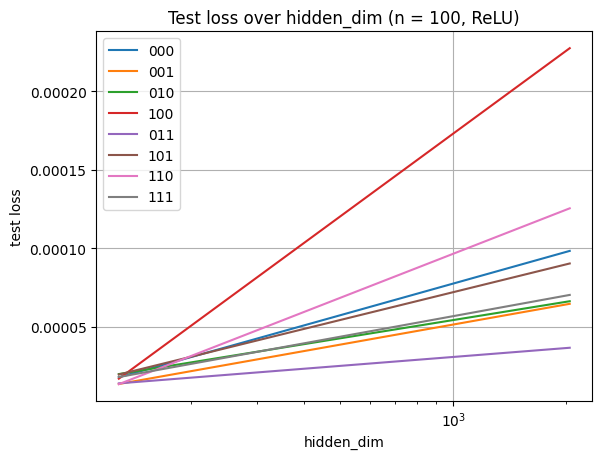

In [ ]:
plot_hiddDim(np.array(testLoss_list), test_centers, hidd_list, lo=100)

---
smaller lr?

Identity + Flipped (111)

In [13]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *

In [14]:
center_list = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [1,1,1]]
var_list = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*5
test_centers = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
test_vars = [ [[0.001, 0, 0], [0, 0.001, 0], [0, 0, 0.001] ]]*8
# hidd_list = [128, 256, 512, 1024, 2048]
hidd_list = [128, 2048]
n_hiddDim = len(hidd_list)
# defaults
n_test = 20
k, lo, hi, step = 10, 100, 110, 10
loss_n = range(lo, hi, step)

In [15]:
eval_list = [[] for _ in range(n_hiddDim)]  # list of test evaluations
losses_list = [[] for _ in range(n_hiddDim)]    # list of training loss histories
test_points_list = [[] for _ in range(n_hiddDim)]    # list of test points
weights_list = [[] for _ in range(n_hiddDim)]   # list of learned model weights
norms_list = [[] for _ in range(n_hiddDim)]     # list of norms of learned model weights

In [16]:
hidden_dim = [hidd_list[0]]
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.0001, use_init="he")
eval_list[0] = evals
losses_list[0] = losses
test_points_list[0] = test_points
weights_list[0] = weights
norms_list[0] = norms

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


In [17]:
hidden_dim = [hidd_list[1]]
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.0001, use_init="he")
eval_list[1] = evals
losses_list[1] = losses
test_points_list[1] = test_points
weights_list[1] = weights
norms_list[1] = norms

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


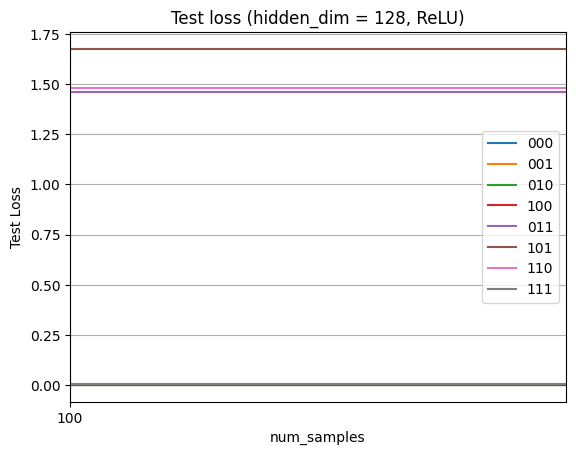

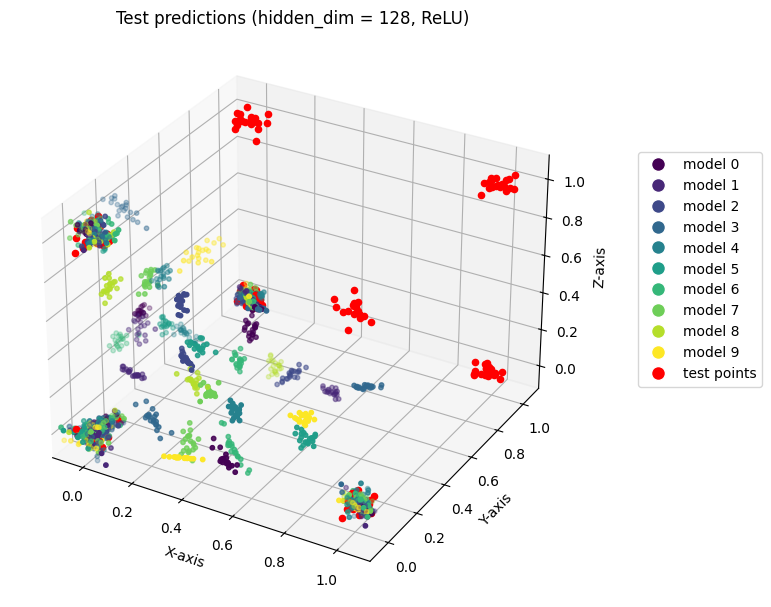

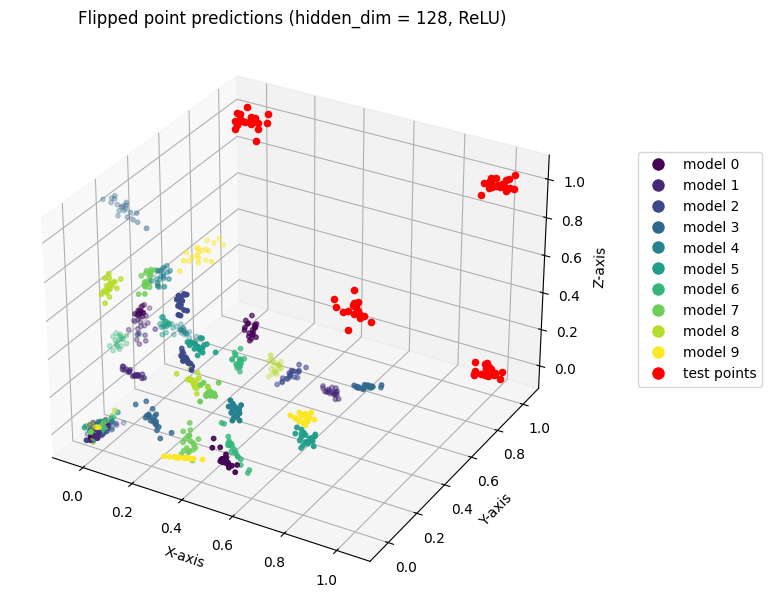

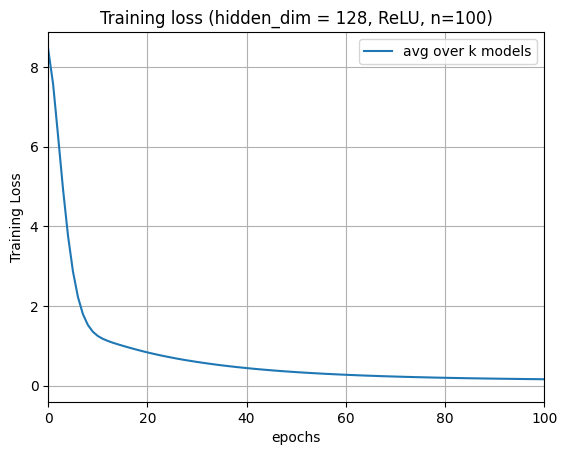

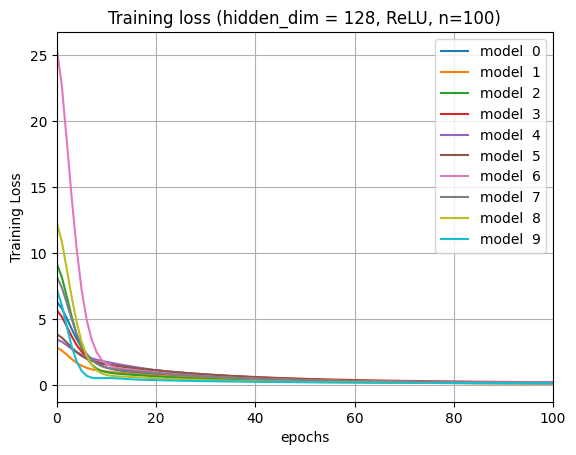

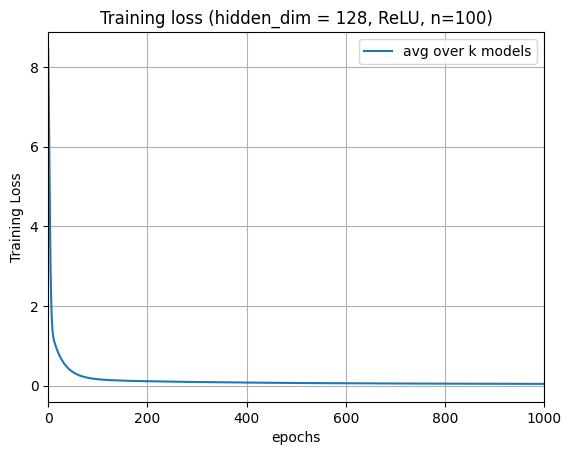

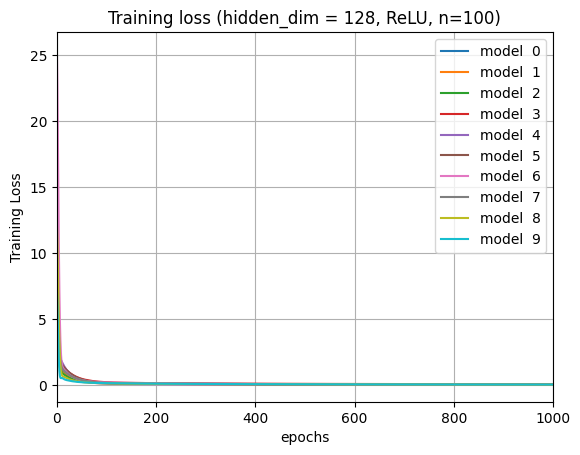

Final training loss for trial 0: 0.015804469119757414
Final training loss for trial 1: 0.015340277925133705
Final training loss for trial 2: 0.012997600715607405
Final training loss for trial 3: 0.023021947592496872
Final training loss for trial 4: 0.013653500704094768
Final training loss for trial 5: 0.018597596092149615
Final training loss for trial 6: 0.01395852374844253
Final training loss for trial 7: 0.017320756800472736
Final training loss for trial 8: 0.014134943252429366
Final training loss for trial 9: 0.01909632282331586


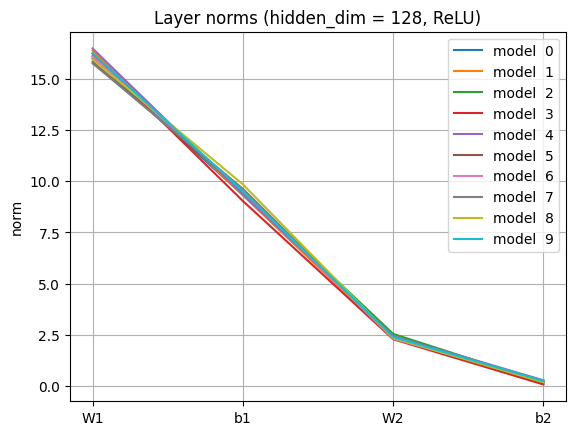

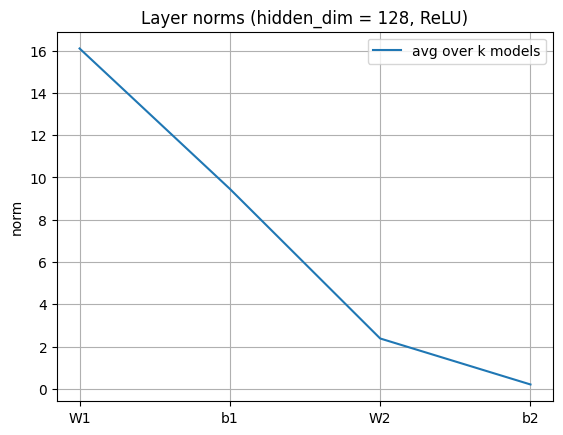

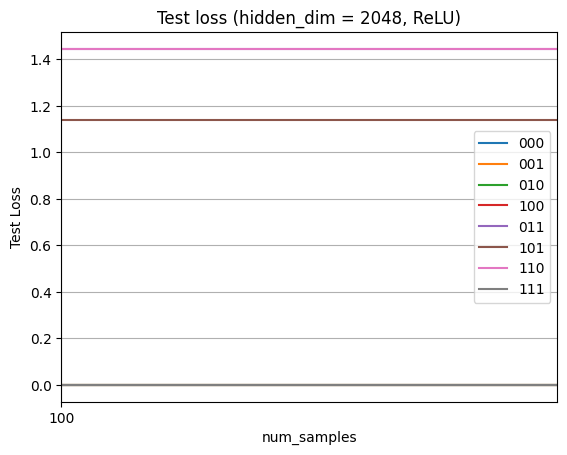

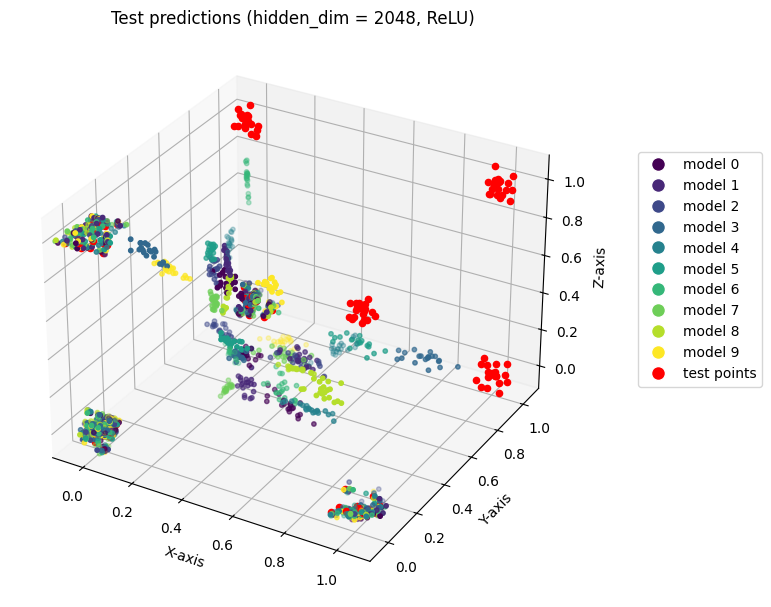

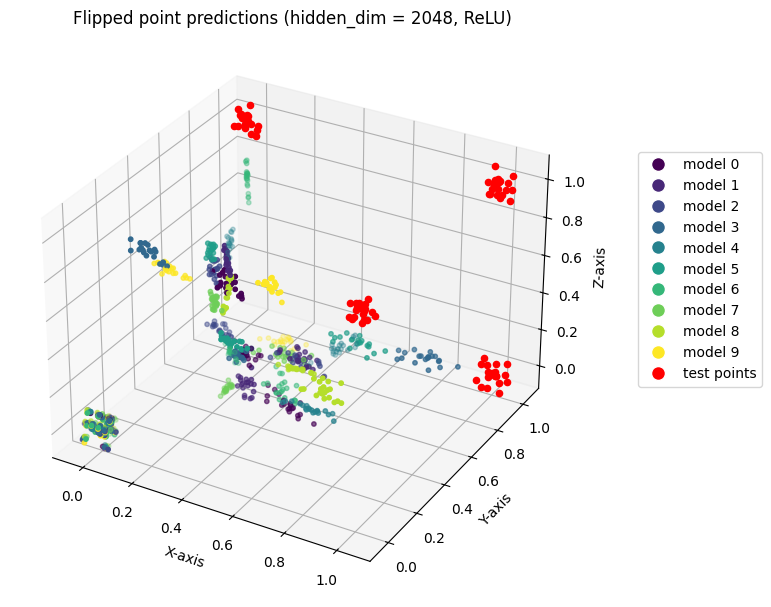

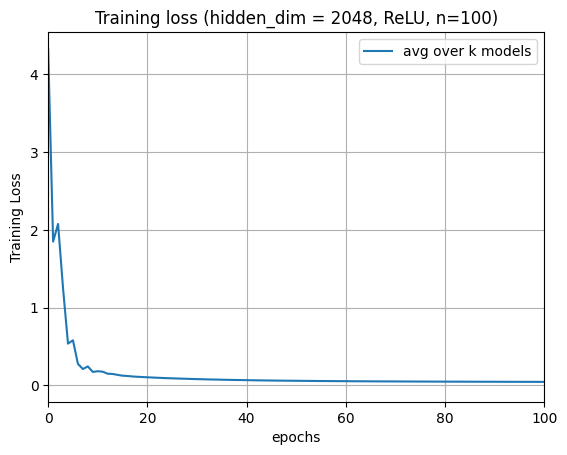

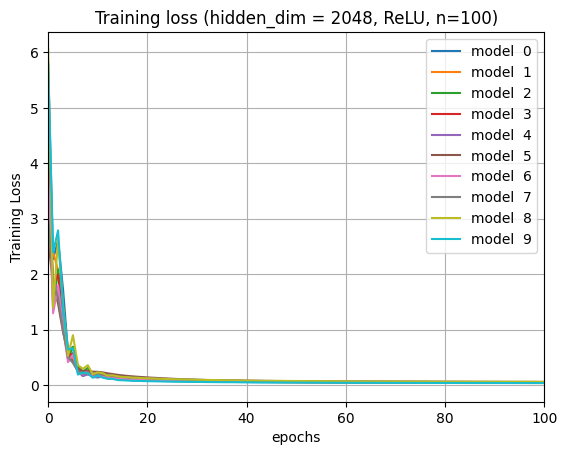

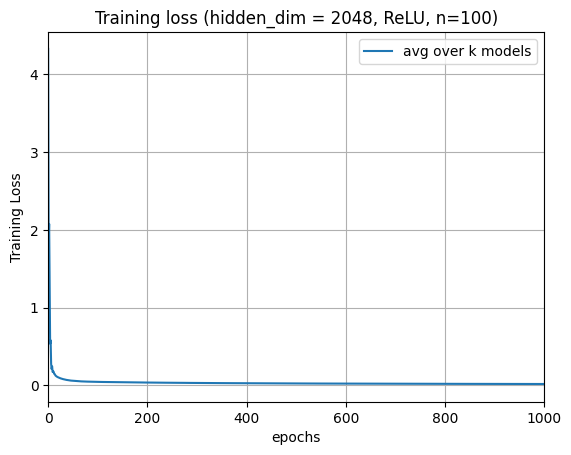

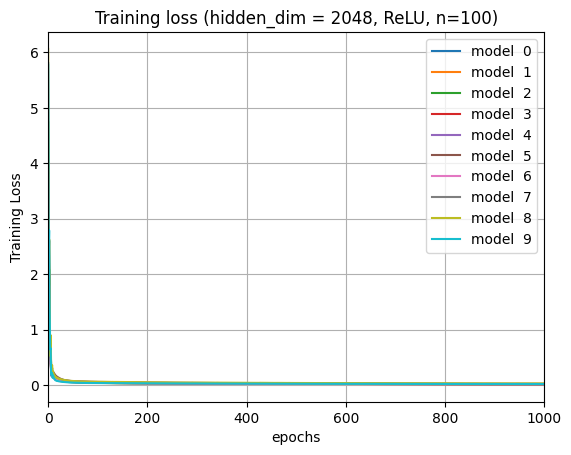

Final training loss for trial 0: 0.001003513447358273
Final training loss for trial 1: 0.0011693923734128475
Final training loss for trial 2: 0.005995515966787934
Final training loss for trial 3: 0.0011714359861798584
Final training loss for trial 4: 0.007880420191213489
Final training loss for trial 5: 0.004048233793582767
Final training loss for trial 6: 0.0014372437435667962
Final training loss for trial 7: 0.006490110827144235
Final training loss for trial 8: 0.01317700621439144
Final training loss for trial 9: 0.006049247138435021


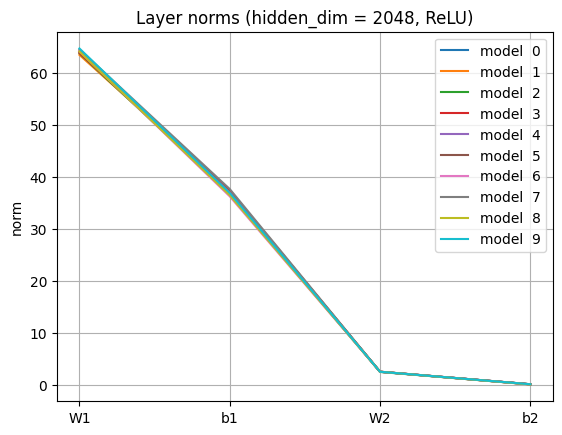

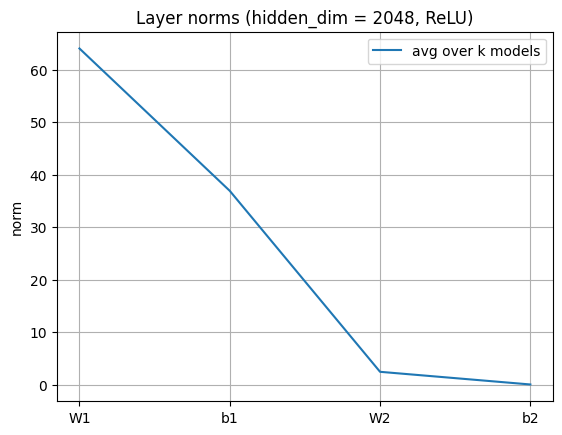

In [18]:
testLoss_list = [[] for _ in range(n_hiddDim)]

for i in range(n_hiddDim):
    hidden_dim = hidd_list[i]
    testLoss = compute_clusterLoss(eval_list[i], flippedIdentity(test_points_list[i]), test_centers)
    plot_clusterTestLoss(np.hstack((testLoss, testLoss)), test_centers, hidden_dim)
    testLoss_list[i] = np.reshape(testLoss, (8))
    
    scatter_testPredictions(eval_list[i], test_points_list[i], hidden_dim, test_ids=range(8))
    scatter_testPredictions(eval_list[i], test_points_list[i], hidden_dim, test_ids=range(4,8), title='Flipped point predictions (hidden_dim = %s, ' % hidden_dim + 'ReLU)')
    
    plot_list = range(len(loss_n))
    plot_trainingLoss(np.mean(losses_list[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=100)
    plot_trainingLoss(losses_list[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=100)
    plot_trainingLoss(np.mean(losses_list[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=1000)
    plot_trainingLoss(losses_list[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=1000)
    for j in range(k):
        print("Final training loss for trial " + str(j) + ": " + str(losses_list[i][0][j][-1]))

    plot_norms(norms_list[i], hidden_dim)
    plot_norms(np.mean(norms_list[i], axis=1, keepdims=True), hidden_dim)

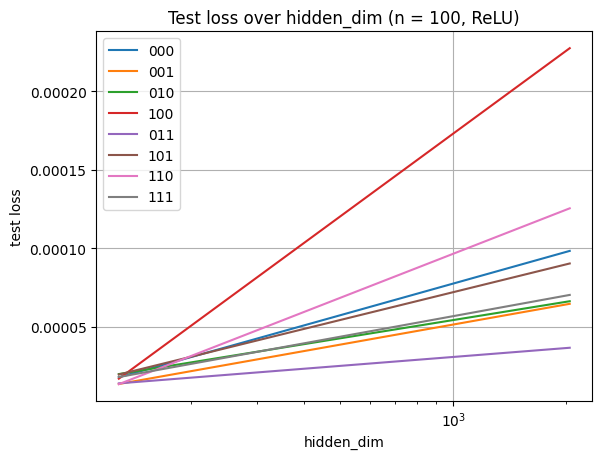

In [ ]:
plot_hiddDim(np.array(testLoss_list), test_centers, hidd_list, lo=100)

---
larger lr?

Identity + Flipped (111)

In [19]:
import concept_generalization
from concept_generalization import *
importlib.reload(concept_generalization)
from concept_generalization import *

In [20]:
center_list = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [1,1,1]]
var_list = [ [[0.01, 0, 0], [0, 0.01, 0], [0, 0, 0.01] ]]*5
test_centers = [[0,0,0], [0,0,1], [0,1,0], [1,0,0], [0,1,1], [1,0,1], [1,1,0], [1,1,1]]
test_vars = [ [[0.001, 0, 0], [0, 0.001, 0], [0, 0, 0.001] ]]*8
# hidd_list = [128, 256, 512, 1024, 2048]
hidd_list = [128, 2048]
n_hiddDim = len(hidd_list)
# defaults
n_test = 20
k, lo, hi, step = 10, 100, 110, 10
loss_n = range(lo, hi, step)

In [21]:
eval_list = [[] for _ in range(n_hiddDim)]  # list of test evaluations
losses_list = [[] for _ in range(n_hiddDim)]    # list of training loss histories
test_points_list = [[] for _ in range(n_hiddDim)]    # list of test points
weights_list = [[] for _ in range(n_hiddDim)]   # list of learned model weights
norms_list = [[] for _ in range(n_hiddDim)]     # list of norms of learned model weights

In [22]:
hidden_dim = [hidd_list[0]]
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.01, use_init="he")
eval_list[0] = evals
losses_list[0] = losses
test_points_list[0] = test_points
weights_list[0] = weights
norms_list[0] = norms

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


In [23]:
hidden_dim = [hidd_list[1]]
evals, test_points, losses, weights, norms = collect_clusterPredictions(hidden_dim, center_list, var_list, test_centers, test_vars, target_fn=flippedIdentity, lr=0.001, use_init="he")
eval_list[1] = evals
losses_list[1] = losses
test_points_list[1] = test_points
weights_list[1] = weights
norms_list[1] = norms

on iteration 0  of k= 10
on iteration 1  of k= 10
on iteration 2  of k= 10
on iteration 3  of k= 10
on iteration 4  of k= 10
on iteration 5  of k= 10
on iteration 6  of k= 10
on iteration 7  of k= 10
on iteration 8  of k= 10
on iteration 9  of k= 10


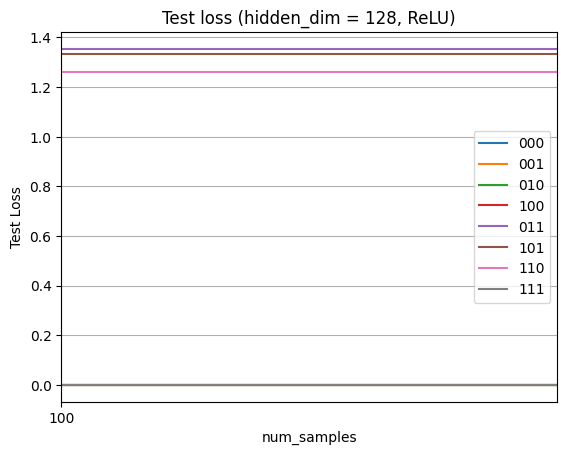

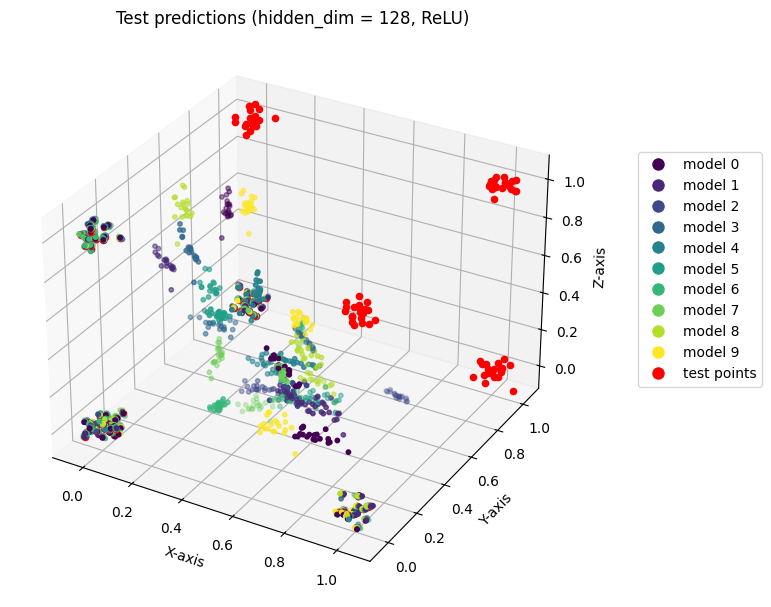

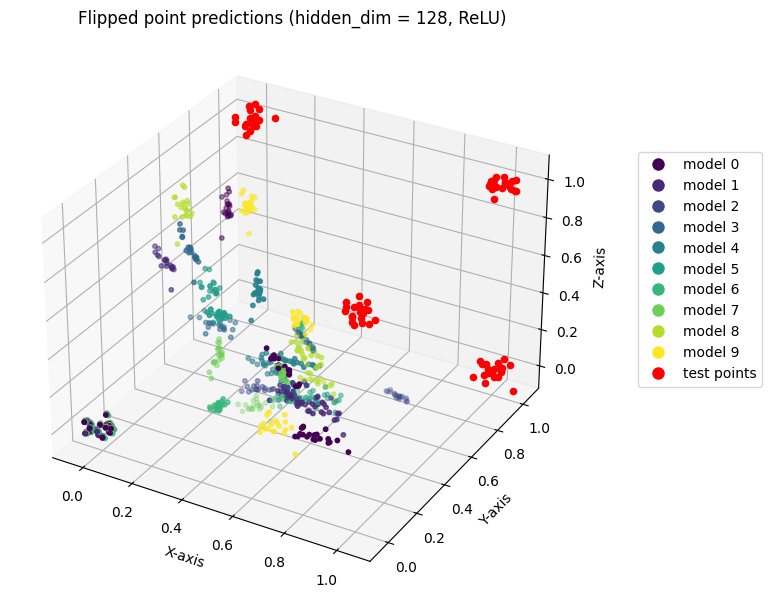

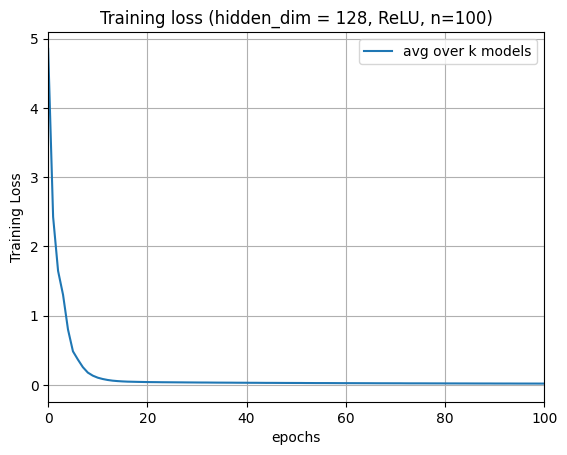

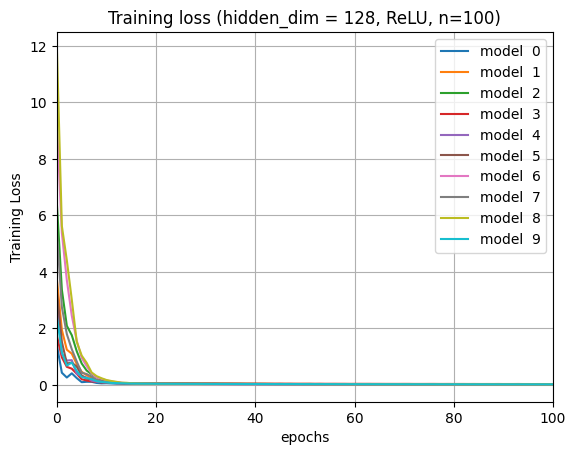

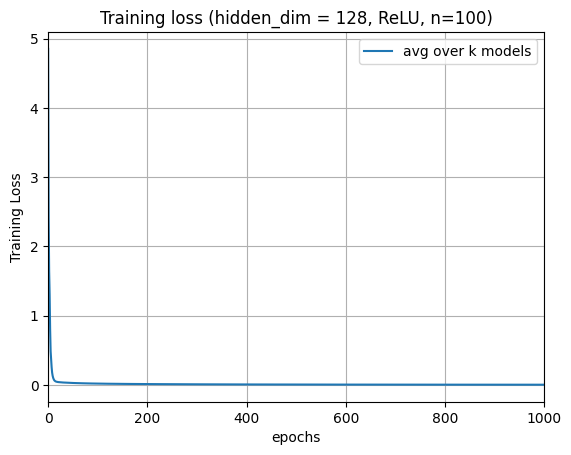

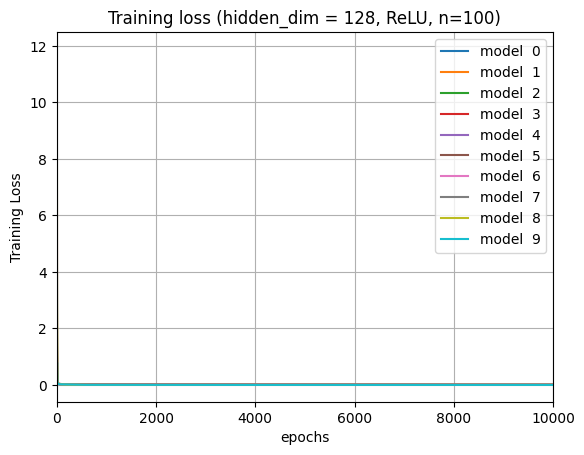

Final training loss for trial 0: 0.0014705307439726312
Final training loss for trial 1: 0.0050958259525941685
Final training loss for trial 2: 0.00333286463865079
Final training loss for trial 3: 0.008317261439515278
Final training loss for trial 4: 0.002081468053802382
Final training loss for trial 5: 0.00010549371654633433
Final training loss for trial 6: 0.0017263548288610764
Final training loss for trial 7: 0.00017563483561389148
Final training loss for trial 8: 0.0001223318304255372
Final training loss for trial 9: 0.00015315975542762317


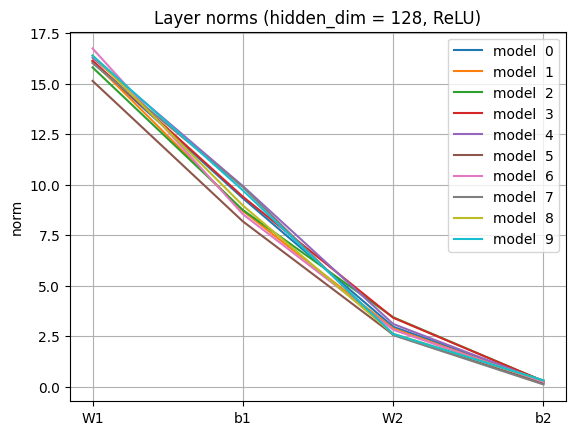

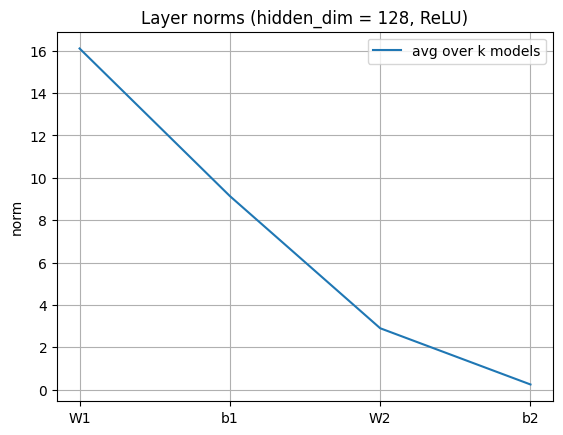

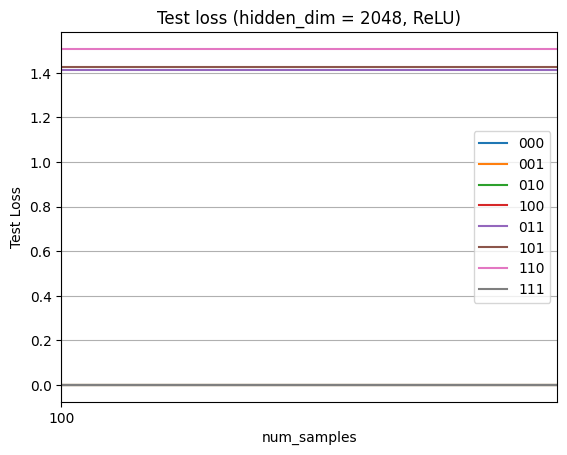

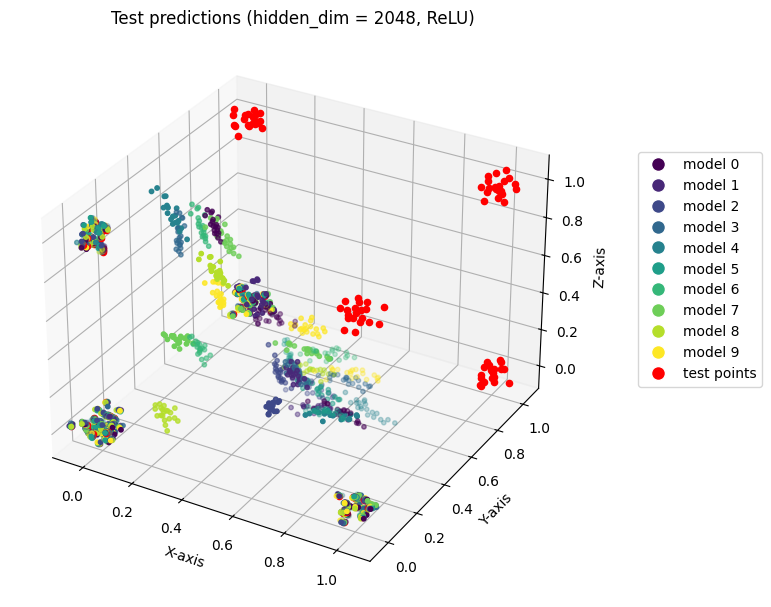

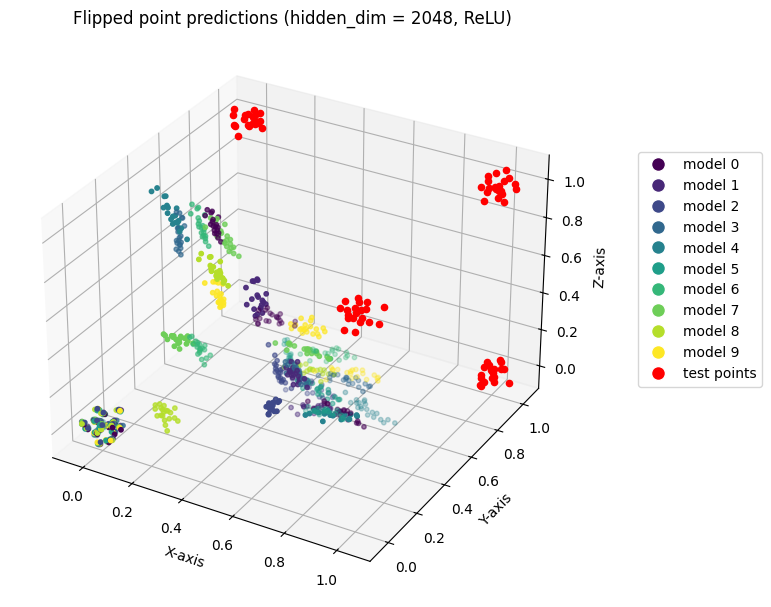

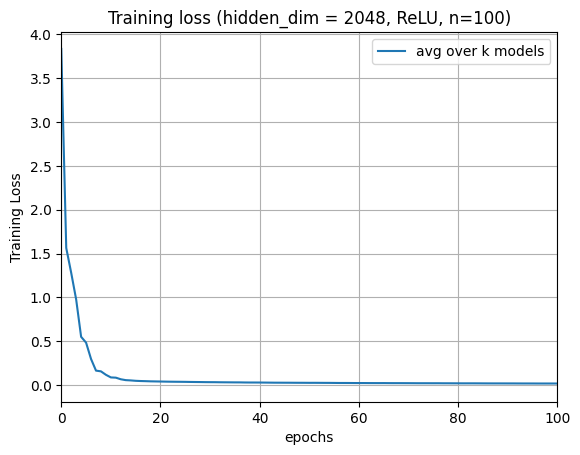

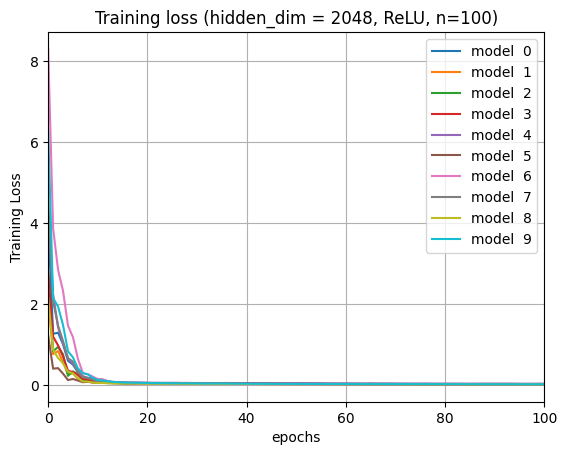

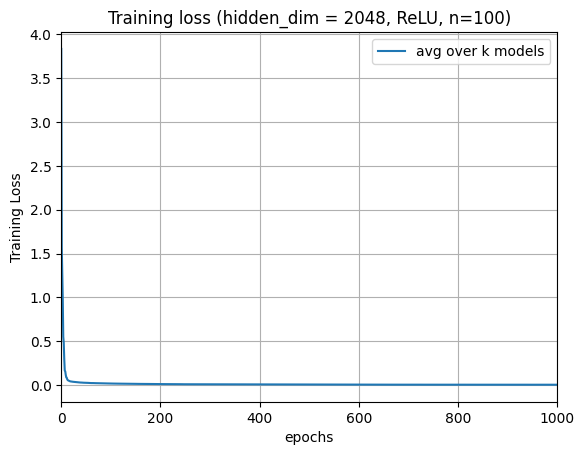

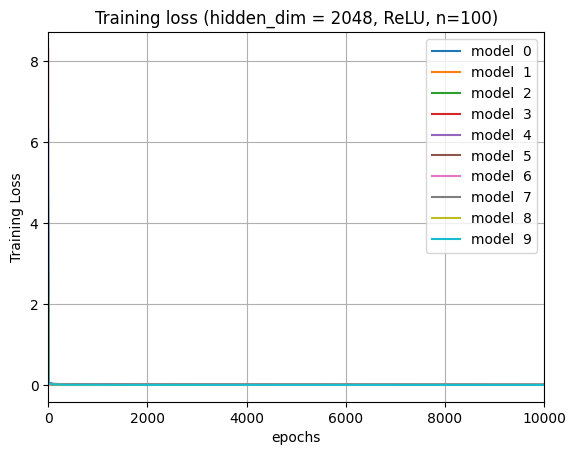

Final training loss for trial 0: 0.0002331040013814345
Final training loss for trial 1: 0.00023638892162125558
Final training loss for trial 2: 0.0029295016720425338
Final training loss for trial 3: 0.00023187371334643103
Final training loss for trial 4: 0.006279396737227216
Final training loss for trial 5: 0.0012905623152619228
Final training loss for trial 6: 0.00027294772371533327
Final training loss for trial 7: 0.0002034980097960215
Final training loss for trial 8: 0.00026262701067025773
Final training loss for trial 9: 0.0002636333883856423


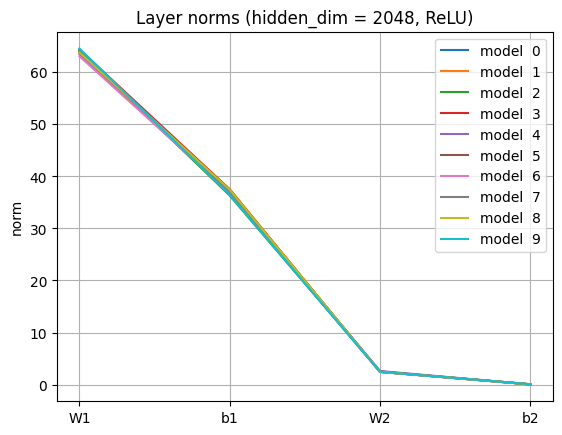

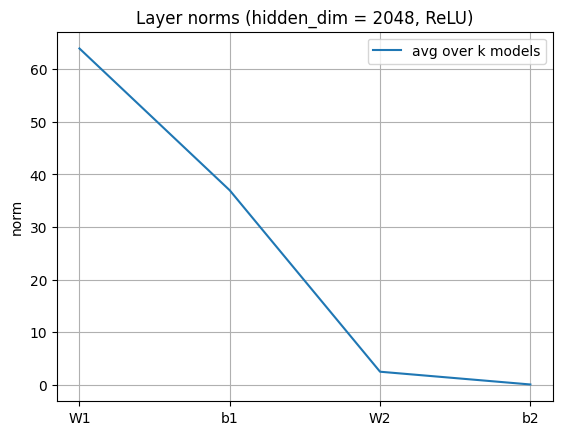

In [25]:
testLoss_list = [[] for _ in range(n_hiddDim)]

for i in range(n_hiddDim):
    hidden_dim = hidd_list[i]
    testLoss = compute_clusterLoss(eval_list[i], flippedIdentity(test_points_list[i]), test_centers)
    plot_clusterTestLoss(np.hstack((testLoss, testLoss)), test_centers, hidden_dim)
    testLoss_list[i] = np.reshape(testLoss, (8))
    
    scatter_testPredictions(eval_list[i], test_points_list[i], hidden_dim, test_ids=range(8))
    scatter_testPredictions(eval_list[i], test_points_list[i], hidden_dim, test_ids=range(4,8), title='Flipped point predictions (hidden_dim = %s, ' % hidden_dim + 'ReLU)')
    
    plot_list = range(len(loss_n))
    plot_trainingLoss(np.mean(losses_list[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=100)
    plot_trainingLoss(losses_list[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=100)
    plot_trainingLoss(np.mean(losses_list[i][0], axis=0, keepdims=True), loss_n, plot_list, hidden_dim, epochs=1000)
    plot_trainingLoss(losses_list[i], loss_n, plot_list, hidden_dim, trials=range(k), epochs=10000)
    for j in range(k):
        print("Final training loss for trial " + str(j) + ": " + str(losses_list[i][0][j][-1]))

    plot_norms(norms_list[i], hidden_dim)
    plot_norms(np.mean(norms_list[i], axis=1, keepdims=True), hidden_dim)

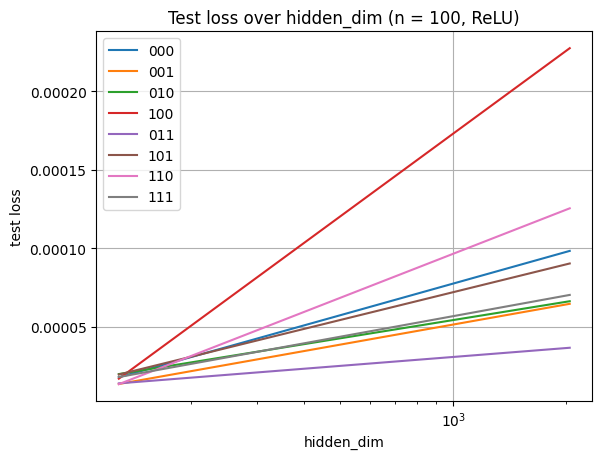

In [ ]:
plot_hiddDim(np.array(testLoss_list), test_centers, hidd_list, lo=100)